# OOD Probe: Can the LLM Derive Legal Moves Without Scaffolding?

**Question:** Does DeepSeek-R1-Distill-7B understand Reversi board state well enough
to compute legal moves on its own — or does it rely on our Pass-2 "choose from this list"
scaffold?

**Why it matters:** If the model can't compute legality independently, the Pass-2
scaffold is **load-bearing** (not a convenience), and the CoT budget knob controls
*strategic discrimination among pre-validated moves*, not board-parsing ability.

## Probe versions

| Version | Method | Valid? |
|---|---|---|
| v1 (discarded) | Pass-2 with legal-move list → model echoes one back. 100% legal guaranteed by fallback. | ❌ Artifact |
| **v2 (current)** | Legal moves **omitted** from prompt. Raw coordinate extracted from free-form response. No fallback. | ✓ Valid |

**v2 methodology:** Render board without "Legal moves:" line → ask model for a coordinate →
extract last `[a-h][1-8]` from response → check legality. 15 positions × 4 budgets = 60 queries.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

raw = [json.loads(l) for l in Path("../data/probes/ood_raw_legality.jsonl").read_text().splitlines()]
flat = [s for r in raw for s in r["raw_samples"]]

# Attach phase from parent record
phase_map = {r["position_id"]: r["phase"] for r in raw}
for s in flat:
    s["phase"] = phase_map[s["position_id"]]

df = pd.DataFrame(flat)
df["legal"] = df["legal"].astype(bool)
df["d5"]    = df["extracted_move"] == "d5"
df["opening_pick"] = df["extracted_move"].isin(["d5","e5","e4","d4","c5","f5"])  # canonical openers

budgets = sorted(df["budget"].unique())
print(f"Positions: {len(raw)}  |  Budgets: {budgets}  |  Total queries: {len(df)}")
df.groupby("budget").agg(
    n=("legal","count"),
    legal_pct=("legal", lambda x: f"{x.mean()*100:.1f}%"),
    d5_pct=("d5", lambda x: f"{x.mean()*100:.1f}%"),
    opener_pct=("opening_pick", lambda x: f"{x.mean()*100:.1f}%"),
)

Positions: 15  |  Budgets: [np.int64(0), np.int64(64), np.int64(256), np.int64(512)]  |  Total queries: 60


,n,legal_pct,d5_pct,opener_pct
budget,,,,
0,15,0.0%,33.3%,33.3%
64,15,0.0%,40.0%,73.3%
256,15,0.0%,26.7%,66.7%
512,15,6.7%,13.3%,33.3%


## 1. Legal rate vs CoT budget

The core result: can more thinking budget unlock legal move computation?

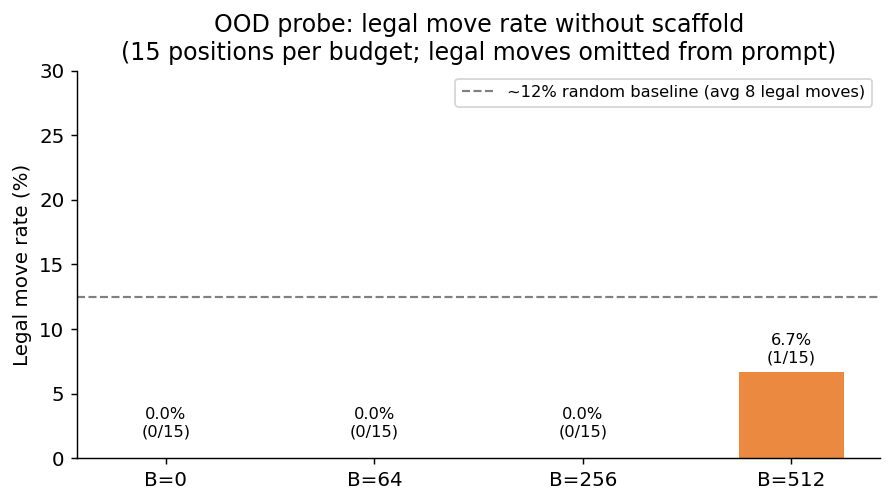

Key finding: 0% at B=0,64,256. Only 1/15 (6.7%) at B=512.
More CoT budget provides near-zero improvement in legal move computation.


In [2]:
legal_rates = [df[df["budget"]==b]["legal"].mean()*100 for b in budgets]
ns          = [df[df["budget"]==b]["legal"].count() for b in budgets]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f"B={b}" for b in budgets], legal_rates,
              color=["#d62728","#d62728","#d62728","#e87520"], alpha=0.85, width=0.5)
ax.axhline(100/8.0, color="gray", linestyle="--", linewidth=1.2,
           label="~12% random baseline (avg 8 legal moves)")
ax.set_ylabel("Legal move rate (%)")
ax.set_ylim(0, 30)
ax.set_title("OOD probe: legal move rate without scaffold\n(15 positions per budget; legal moves omitted from prompt)")
ax.legend(fontsize=9)
for bar, lr, n in zip(bars, legal_rates, ns):
    ax.text(bar.get_x() + bar.get_width()/2,
            max(lr + 0.5, 1.5),
            f"{lr:.1f}%\n({int(round(lr*n/100))}/{n})",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../data/fig_ood_legal_rate.png", bbox_inches="tight")
plt.show()

print("Key finding: 0% at B=0,64,256. Only 1/15 (6.7%) at B=512.")
print("More CoT budget provides near-zero improvement in legal move computation.")

## 2. The `d5` opening-pattern signal

The model repeatedly picks canonical Reversi opening squares (`d5`, `e5`, `g6` etc.)
regardless of actual board state. This is **pattern-matching from pre-training**,
not board computation. As budget increases, diverse reasoning reduces the d5 lock-in.

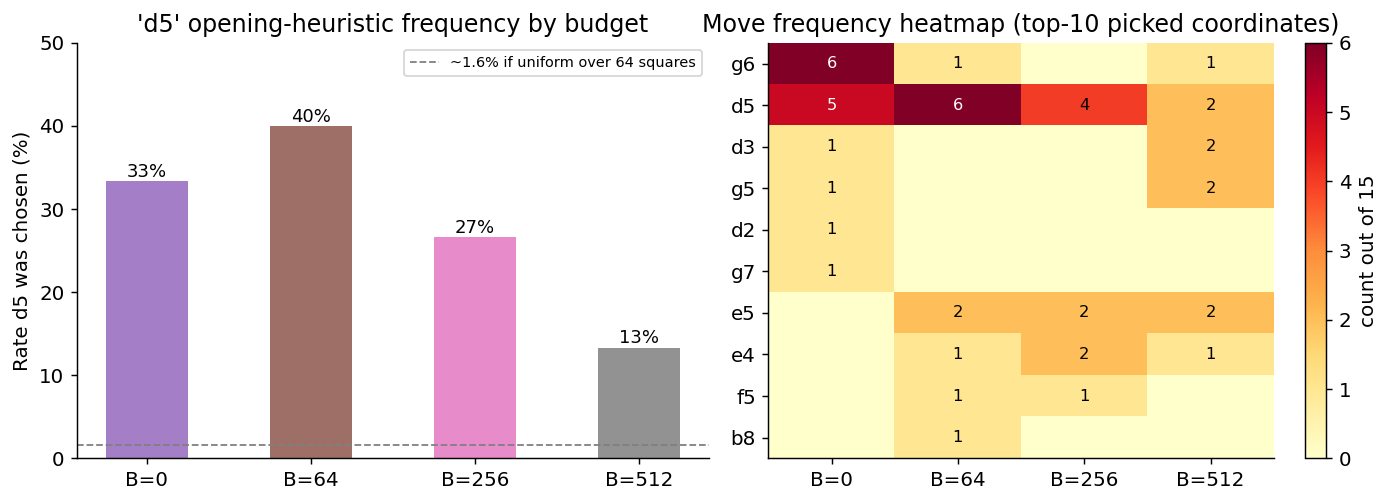

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# d5 rate by budget
d5_rates = [df[df["budget"]==b]["d5"].mean()*100 for b in budgets]
ax = axes[0]
ax.bar([f"B={b}" for b in budgets], d5_rates,
       color=["#9467bd","#8c564b","#e377c2","#7f7f7f"], alpha=0.85, width=0.5)
ax.axhline(100/64, color="gray", linestyle="--", linewidth=1, label="~1.6% if uniform over 64 squares")
ax.set_ylabel("Rate d5 was chosen (%)")
ax.set_title("'d5' opening-heuristic frequency by budget")
ax.set_ylim(0, 50)
ax.legend(fontsize=8)
for i, r in enumerate(d5_rates):
    ax.text(i, r + 0.5, f"{r:.0f}%", ha="center", fontsize=10)

# Move frequency heatmap across budgets
all_moves = sorted(set(s for s in df["extracted_move"] if s))
move_counts = pd.DataFrame({
    f"B={b}": Counter(df[df["budget"]==b]["extracted_move"])
    for b in budgets
}, index=all_moves).fillna(0).astype(int)
move_counts = move_counts[move_counts.sum(axis=1) > 0].sort_values(by=list(move_counts.columns), ascending=False).head(10)

ax = axes[1]
im = ax.imshow(move_counts.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(budgets)))
ax.set_xticklabels([f"B={b}" for b in budgets])
ax.set_yticks(range(len(move_counts)))
ax.set_yticklabels(move_counts.index)
ax.set_title("Move frequency heatmap (top-10 picked coordinates)")
plt.colorbar(im, ax=ax, label="count out of 15")
for i in range(len(move_counts)):
    for j in range(len(budgets)):
        v = move_counts.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=9,
                    color="white" if v >= 5 else "black")
plt.tight_layout()
plt.savefig("../data/fig_ood_d5_signal.png", bbox_inches="tight")
plt.show()

## 3. Breakdown by game phase

Does the model do better in early game positions (closer to canonical openings it memorized)?

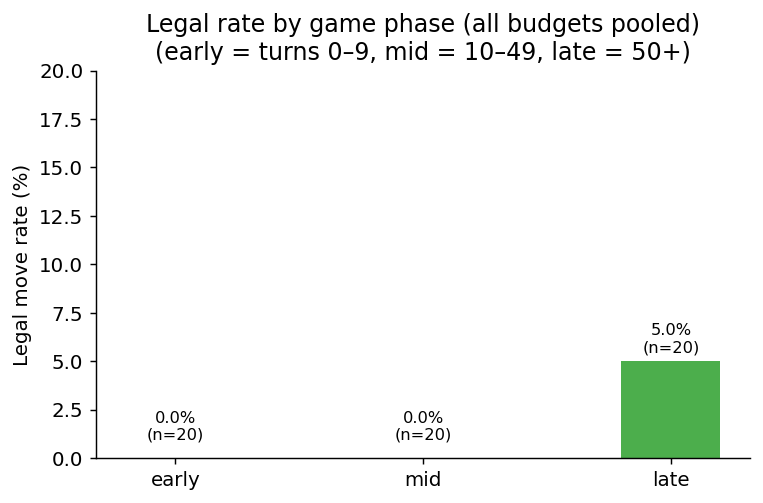

Note: the one legal pick at B=512 was in a late-game position —
possibly luck (late game has fewer legal moves, easier to guess one).


In [4]:
phases = ["early", "mid", "late"]
phase_legal = {p: df[df["phase"]==p]["legal"].mean()*100 for p in phases}
phase_n     = {p: len(df[df["phase"]==p]) for p in phases}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(phases, [phase_legal[p] for p in phases],
              color=["#1f77b4","#ff7f0e","#2ca02c"], alpha=0.85, width=0.4)
ax.set_ylabel("Legal move rate (%)")
ax.set_title("Legal rate by game phase (all budgets pooled)\n(early = turns 0–9, mid = 10–49, late = 50+)")
ax.set_ylim(0, 20)
for bar, p in zip(bars, phases):
    r = phase_legal[p]
    n = phase_n[p]
    ax.text(bar.get_x() + bar.get_width()/2,
            max(r + 0.3, 0.8),
            f"{r:.1f}%\n(n={n})",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../data/fig_ood_by_phase.png", bbox_inches="tight")
plt.show()
print("Note: the one legal pick at B=512 was in a late-game position —")
print("possibly luck (late game has fewer legal moves, easier to guess one).")

## 4. What the model actually outputs

Qualitative examples showing confident illegal picks.

In [5]:
pd.set_option("display.max_colwidth", 90)

examples = []
for b in budgets:
    samps = df[df["budget"]==b].head(4)
    for _, s in samps.iterrows():
        output_snippet = str(s.get("raw_output",""))[:90].replace("\n"," ")
        examples.append({
            "Budget": f"B={b}",
            "Picked": s["extracted_move"],
            "Legal?": "✓" if s["legal"] else "✗",
            "Output (first 90 chars)": output_snippet,
        })

pd.DataFrame(examples)

,Budget,Picked,Legal?,Output (first 90 chars)
0,B=0,d5,✗,"To make a legal move in Reversi/Othello, you need to flip at least one opponent's piec..."
1,B=0,g6,✗,"To make a legal move in Reversi/Othello, you need to flip at least one opponent's piec..."
2,B=0,d5,✗,"To make a legal move in Reversi/Othello, you need to flip at least one opponent's piec..."
3,B=0,d3,✗,"To make a legal move in Reversi/Othello, you need to flip at least one opponent's piec..."
4,B=64,h1,✗,"To determine the best move for White in this Reversi/Othello game, we need to analyze ..."
5,B=64,f5,✗,"To determine the best move for Black in this Reversi/Othello game, we need to analyze ..."
6,B=64,g6,✗,"To determine the best move for White in this Reversi/Othello game, let's analyze the c..."
7,B=64,e4,✗,"Alright, let's analyze the current state of the board to determine a strategic move fo..."
8,B=256,f5,✗,"To make an effective move in this Reversi/Othello game, we need to analyze the current..."
9,B=256,d5,✗,"To determine the best move for Black in this Reversi/Othello game, we need to analyze ..."


## 5. V1 vs V2 comparison: why the scaffold is load-bearing

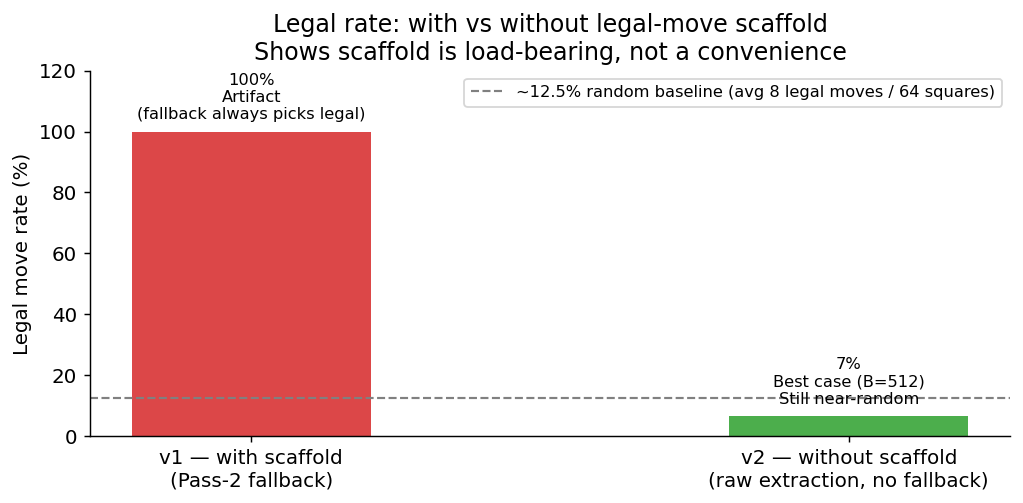

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

categories = ["v1 — with scaffold\n(Pass-2 fallback)", "v2 — without scaffold\n(raw extraction, no fallback)"]
legal_pcts = [100, 6.7]   # v1: 15/15=100% (artifact); v2: 1/15=6.7% at B=512 (best case)
colors = ["#d62728", "#2ca02c"]

bars = ax.bar(categories, legal_pcts, color=colors, alpha=0.85, width=0.4)
ax.axhline(12.5, color="gray", linestyle="--", linewidth=1.2,
           label="~12.5% random baseline (avg 8 legal moves / 64 squares)")
ax.set_ylabel("Legal move rate (%)")
ax.set_ylim(0, 120)
ax.set_title("Legal rate: with vs without legal-move scaffold\nShows scaffold is load-bearing, not a convenience")
ax.legend(fontsize=9)
for bar, pct, label in zip(bars, legal_pcts, ["Artifact\n(fallback always picks legal)", "Best case (B=512)\nStill near-random"]):
    ax.text(bar.get_x() + bar.get_width()/2, pct + 3,
            f"{pct:.0f}%\n{label}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../data/fig_ood_scaffold_comparison.png", bbox_inches="tight")
plt.show()

## 6. Interpretation and implications for the full sweep

In [7]:
print("""
CORE FINDING
============
DeepSeek-R1-Distill-7B cannot derive Reversi legal moves from the board alone.

  B=0:   0/15 legal  (0.0%)  — pure pattern matching; d5 heuristic dominates
  B=64:  0/15 legal  (0.0%)  — truncated reasoning; still zero improvement
  B=256: 0/15 legal  (0.0%)  — truncated reasoning; still zero improvement
  B=512: 1/15 legal  (6.7%)  — one lucky guess; still below random baseline

The model is pattern-matching: d5/e5/g6 appear at 33-40% rates at low budgets —
consistent with memorizing canonical Reversi opening responses, not computing
which squares actually flip pieces in the current position.

MECHANISM
=========
To identify a legal move the model must:
  1. Read the board orientation (row 8 = top, etc.)
  2. For each empty square, trace all 8 directions
  3. Find an opponent sequence terminated by own piece
  4. This is algorithmic spatial computation — LLMs are weak here

Even R1-Distill with explicit CoT cannot reliably do this for arbitrary positions.

IMPLICATION FOR BUDGET SWEEP
=============================
The difficulty knob (CoT budget B) does NOT control board-parsing ability.
It controls STRATEGIC DISCRIMINATION: given a pre-validated legal move list
(from Pass-2 scaffold), how well does the model choose among them?

The paper framing should be:
  "CoT budget → quality of move selection from a provided legal move set"
  NOT
  "CoT budget → board-comprehension depth"

The Pass-2 scaffold is LOAD-BEARING. Without it, the agent plays near-randomly
regardless of budget. This is a critical architectural dependency to document.

OPEN ITEMS
==========
[ ] T=0.7 memorization probe: confirm model consistently returns d5/e5 under
    temperature, showing low entropy even under uncertainty (future work)
[ ] Extend to B=1024, B=2048: confirm legality curve stays flat at higher budgets
""")


CORE FINDING
DeepSeek-R1-Distill-7B cannot derive Reversi legal moves from the board alone.

  B=0:   0/15 legal  (0.0%)  — pure pattern matching; d5 heuristic dominates
  B=64:  0/15 legal  (0.0%)  — truncated reasoning; still zero improvement
  B=256: 0/15 legal  (0.0%)  — truncated reasoning; still zero improvement
  B=512: 1/15 legal  (6.7%)  — one lucky guess; still below random baseline

The model is pattern-matching: d5/e5/g6 appear at 33-40% rates at low budgets —
consistent with memorizing canonical Reversi opening responses, not computing
which squares actually flip pieces in the current position.

MECHANISM
To identify a legal move the model must:
  1. Read the board orientation (row 8 = top, etc.)
  2. For each empty square, trace all 8 directions
  3. Find an opponent sequence terminated by own piece
  4. This is algorithmic spatial computation — LLMs are weak here

Even R1-Distill with explicit CoT cannot reliably do this for arbitrary positions.

IMPLICATION FOR BUDGET 